In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("spotify_colombia_2024.csv")
df.head()

,cancion,artista,genero,region,popularidad,duracion_seg,streams_millones
0,Me Llamas,Carlos Vives,Vallenato,Barranquilla,88.0,255,4.42
1,Mi Libertad,Peter Manjarrés,Vallenato,Cali,63.0,183,3.58
2,Latinoamérica,Maluma,Reggaeton,Bucaramanga,81.0,194,3.84
3,Antes,Systema Solar,Afrobeat,Cartagena,47.0,210,3.16
4,Ojos Así,Jorge Celedón,Vallenato,Barranquilla,80.0,205,2.73


In [ ]:


print("Dimensiones: ", df.shape)

print("Tipos de datos: ", df.dtypes)

print("Tenemos nulos? ", df.isnull().sum())

Dimensiones:  (600, 7)
Tipos de datos:  cancion                 str
artista                 str
genero                  str
region                  str
popularidad         float64
duracion_seg          int64
streams_millones    float64
dtype: object
Tenemos nulos?  cancion              0
artista              0
genero               0
region               0
popularidad          8
duracion_seg         0
streams_millones    10
dtype: int64


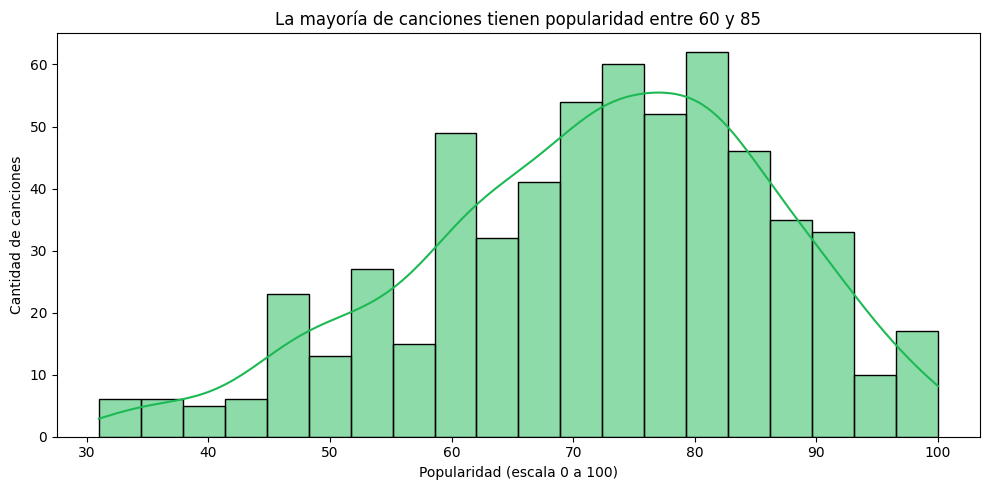

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="popularidad", bins=20, kde=True, color="#1DB954")

plt.title("La mayoría de canciones tienen popularidad entre 60 y 85")
plt.xlabel("Popularidad (escala 0 a 100)")
plt.ylabel("Cantidad de canciones")
plt.tight_layout()
plt.show()

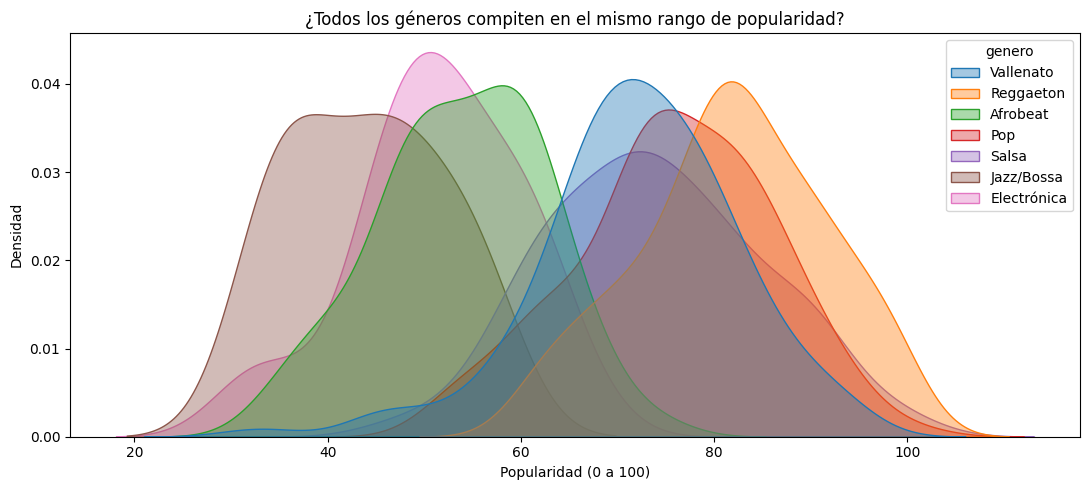

In [12]:
plt.figure(figsize=(11, 5))

sns.kdeplot(data=df, x="popularidad", hue="genero",
            fill=True, alpha=0.4, common_norm=False)

plt.title("¿Todos los géneros compiten en el mismo rango de popularidad?")
plt.xlabel("Popularidad (0 a 100)")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

C:\Users\anaa_\AppData\Local\Temp\ipykernel_27200\2369481005.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="genero", y="popularidad",


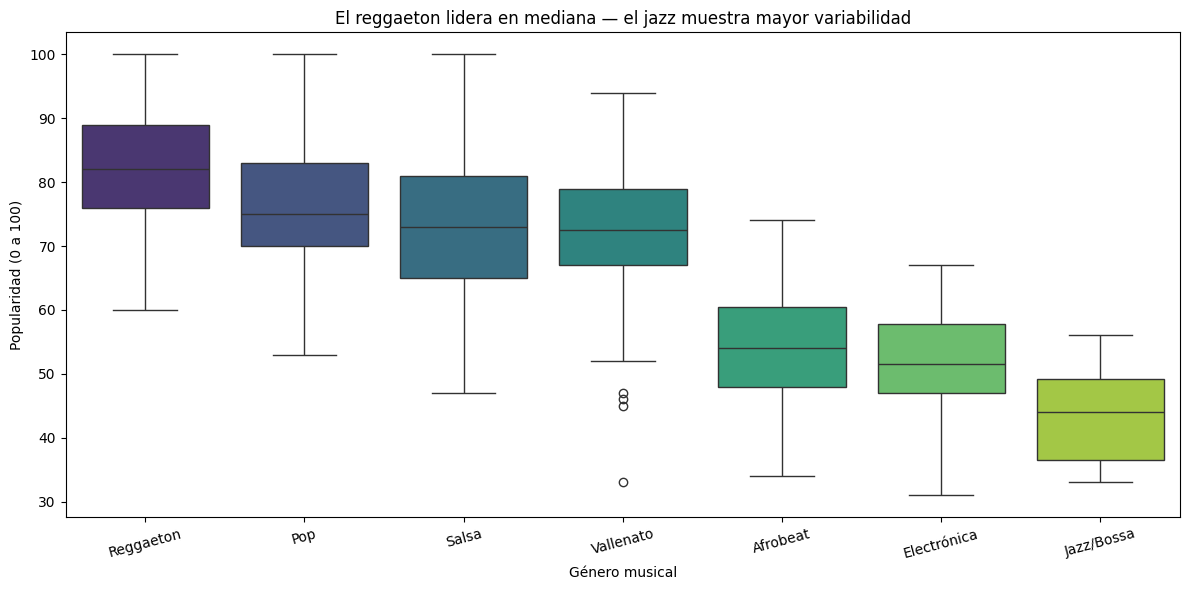

In [13]:
orden_generos = (df.groupby("genero")["popularidad"]
                   .median()
                   .sort_values(ascending=False)
                   .index)

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="genero", y="popularidad",
            order=orden_generos, palette="viridis")

plt.title("El reggaeton lidera en mediana — el jazz muestra mayor variabilidad")
plt.xlabel("Género musical")
plt.ylabel("Popularidad (0 a 100)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\anaa_\AppData\Local\Temp\ipykernel_27200\2055922417.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region",


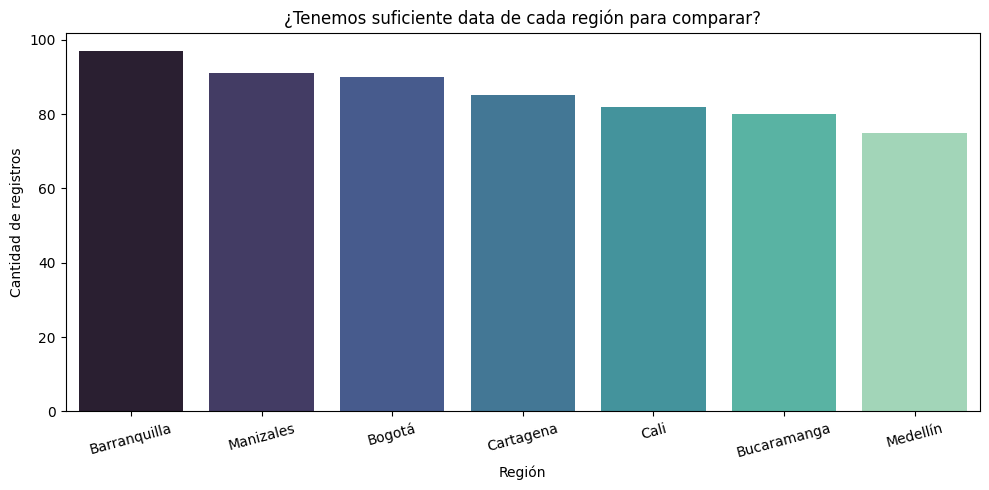

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="region",
              order=df["region"].value_counts().index,
              palette="mako")

plt.title("¿Tenemos suficiente data de cada región para comparar?")
plt.xlabel("Región")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

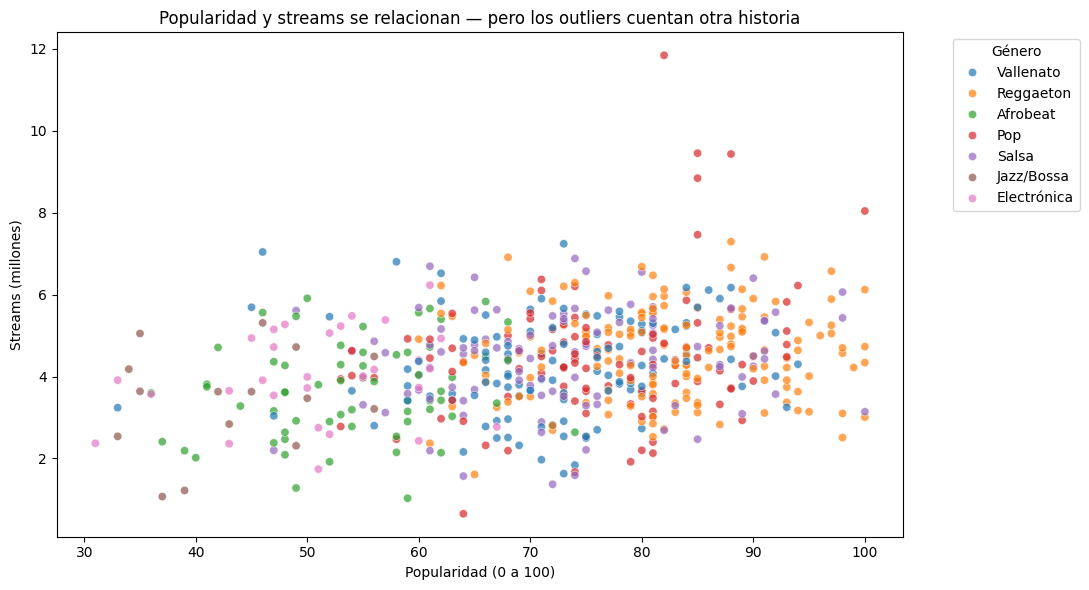

In [15]:
plt.figure(figsize=(11, 6))

sns.scatterplot(data=df, x="popularidad", y="streams_millones",
                hue="genero", alpha=0.7, palette="tab10")

plt.title("Popularidad y streams se relacionan — pero los outliers cuentan otra historia")
plt.xlabel("Popularidad (0 a 100)")
plt.ylabel("Streams (millones)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Género")
plt.tight_layout()
plt.show()

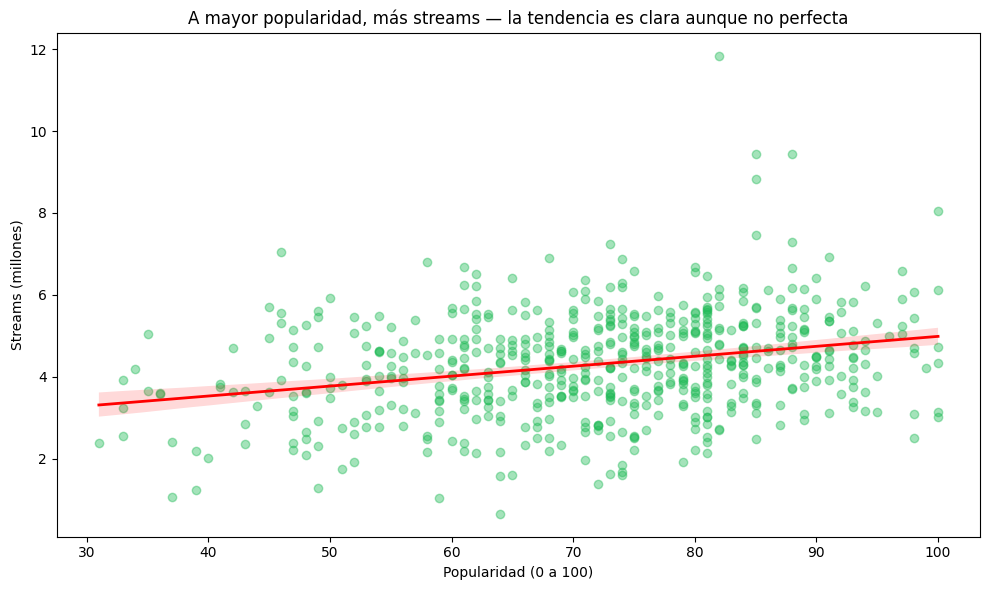

In [16]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x="popularidad", y="streams_millones",
            scatter_kws={"alpha": 0.4, "color": "#1DB954"},
            line_kws={"color": "red", "linewidth": 2})

plt.title("A mayor popularidad, más streams — la tendencia es clara aunque no perfecta")
plt.xlabel("Popularidad (0 a 100)")
plt.ylabel("Streams (millones)")
plt.tight_layout()
plt.show()

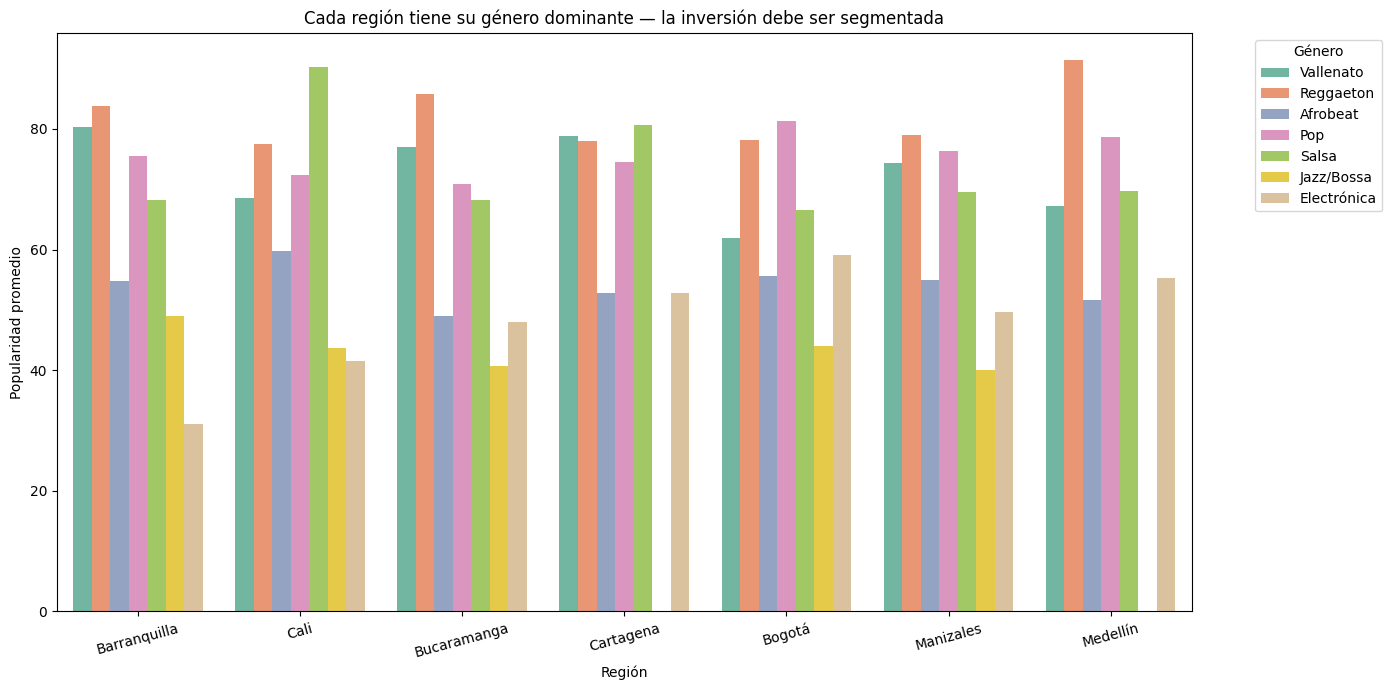

In [17]:
plt.figure(figsize=(14, 7))

sns.barplot(data=df, x="region", y="popularidad",
            hue="genero", estimator="mean",
            palette="Set2", errorbar=None)

plt.title("Cada región tiene su género dominante — la inversión debe ser segmentada")
plt.xlabel("Región")
plt.ylabel("Popularidad promedio")
plt.xticks(rotation=15)
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

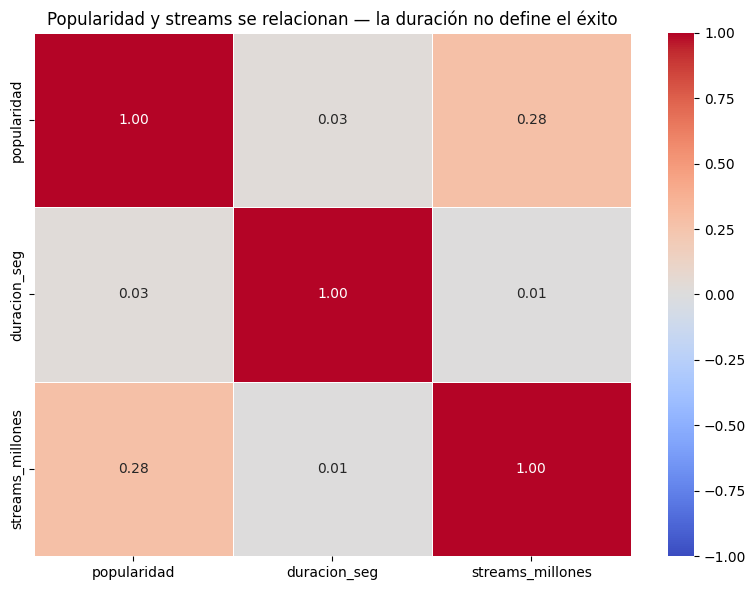

In [18]:
numericas = df[["popularidad", "duracion_seg", "streams_millones"]]
matriz_correlacion = numericas.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_correlacion, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            center=0, linewidths=0.5)

plt.title("Popularidad y streams se relacionan — la duración no define el éxito")
plt.tight_layout()
plt.show()